<a href="https://colab.research.google.com/github/thiendoan0401-hue/018793021_CMPE188_Lab2/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn import metrics

In [3]:
df = pd.read_csv(r'/separable2vs8.csv', index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 985 entries, 1 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      985 non-null    float64
 1   x2      985 non-null    float64
 2   y       985 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 30.8 KB


<Axes: xlabel='x1', ylabel='x2'>

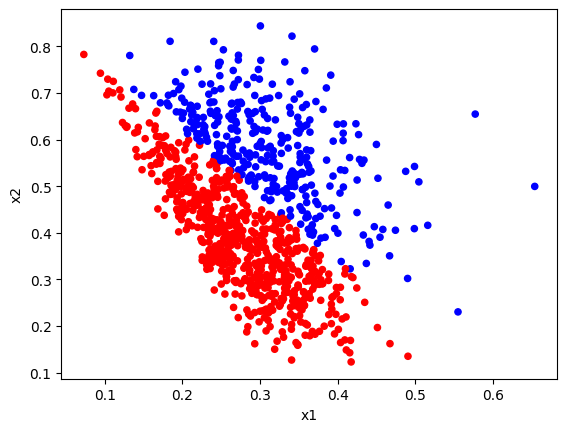

In [4]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)

In [5]:
df.head()

,x1,x2,y
x0,,,
1,0.458248,0.407339,-1
1,0.308186,0.236474,1
1,0.170111,0.590144,1
1,0.239096,0.424140,1
1,0.305740,0.475571,-1


In [6]:
X = np.array(df[['x1', 'x2']])
y = np.array(df[['y']])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=60, random_state=45
)

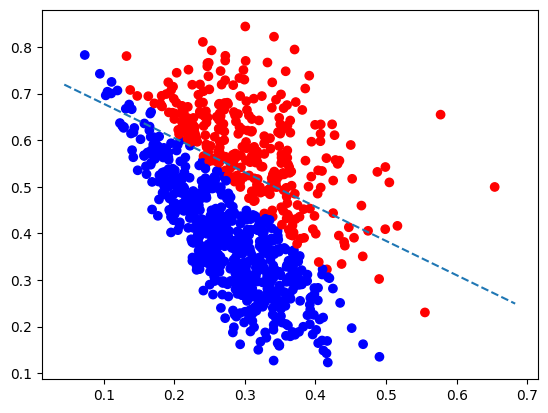

In [8]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train.ravel())
colors=[]
for y_col in y_train:
  if y_col == 1:
      colors.append('b')
  else:
      colors.append('r')

plt.scatter(X_train[:,0], X_train[:,1], color=colors)

intercept = -lr.intercept_[0]/lr.coef_[0,1]
slope = -lr.coef_[0,0]/lr.coef_[0,1]

axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )

In [9]:
y_pred_train = lr.predict(X_train)
metrics.confusion_matrix(y_train, y_pred_train)

array([[239,  74],
       [ 14, 598]])

In [10]:
metrics.accuracy_score(y_train, y_pred_train)

0.9048648648648648

In [11]:
y_pred = lr.predict(X_test)

metrics.confusion_matrix(y_test, y_pred)

array([[14,  9],
       [ 2, 35]])

In [12]:
metrics.accuracy_score(y_test, y_pred)

0.8166666666666667

In [13]:
metrics.precision_score(y_test, y_pred)

0.7954545454545454

In [14]:
metrics.f1_score(y_test, y_pred)

0.8641975308641975

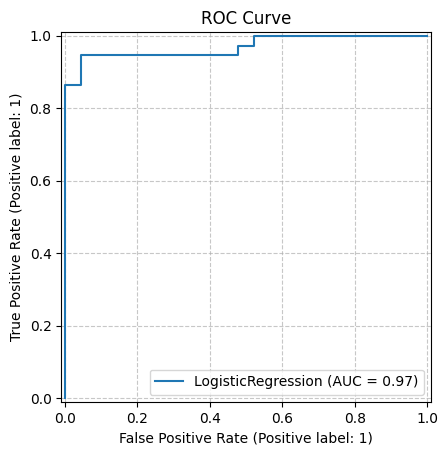

In [15]:
fig_roc, ax_roc = plt.subplots(1, 1)
metrics.RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=ax_roc)
plt.title('ROC Curve')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()